In [2]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [ ]:
#file loaded to dataframe
df = pd.read_csv("housing.csv")

#first 5 lines of the table
df.head()

In [ ]:
#preprocessing

#yes/no columns ko 1/0 me change krna
binary_columns = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
'airconditioning', 'prefarea']

def binary_map(x):
    return x.map({'yes':1, 'no':0})

df[binary_columns] = df[binary_columns].apply(binary_map)

df.head()

In [ ]:
# furnishingstatus ko one hot encoding krna
# It'll create new columns like furnishingstatus_furnished, 
# furnishingstatus_semi-furnished, furnishingstatus_unfurnished

status = pd.get_dummies(df['furnishingstatus'], drop_first=True)

# Ab in naye columns ko purane data (df) ke saath jod do
df = pd.concat([df, status], axis=1)


# Ab purane 'furnishingstatus' column ki zaroorat nahi hai 
# (kyunki humne naye bana liye), toh usse hata do
df.drop('furnishingstatus', axis=1, inplace=True)

# tru/false ko 1/0 me convert krna
df[['semi-furnished', 'unfurnished']] = df[['semi-furnished', 'unfurnished']].astype(int)

df.head()


In [ ]:
df.info

In [7]:
# y = target which we need
y = df.pop('price')

# x = features
X = df


In [ ]:
# 70% Training: Model ko sikhane ke liye.
# 30% Testing: Model ka test lene ke liye.

from sklearn.model_selection import train_test_split

# Randomly data ko tod rahe hain (random_state=100 taaki humara result same aaye)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)

print("Training Data Size:", X_train.shape)
print("Testing Data Size:", X_test.shape)

In [ ]:
# Training Model

from sklearn.linear_model import LinearRegression

# new model
lm = LinearRegression()

# training model
lm.fit(X_train, y_train)

print("Model Trained Successfully!")


In [ ]:
from sklearn.metrics import r2_score

# Prediction on test data
y_pred = lm.predict(X_test)

# Calculate R2 Score
score = r2_score(y_test, y_pred)

print("R2 Score:", score, " Accuracy: ", score*100,"%")

In [ ]:
import pickle
import os

os.makedirs('model', exist_ok=True)
file_path = os.path.join('model', 'house_model.pkl')
# saving the model
pickle.dump(lm, open(file_path, 'wb'))

print("Saved Model location:", file_path)


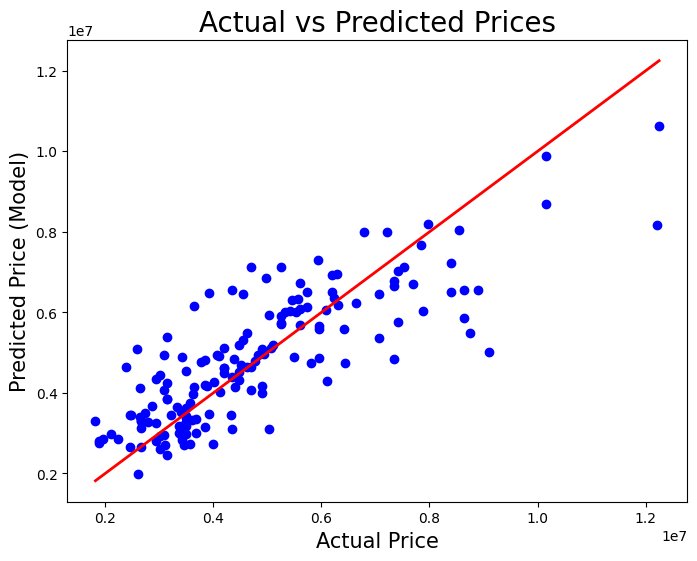

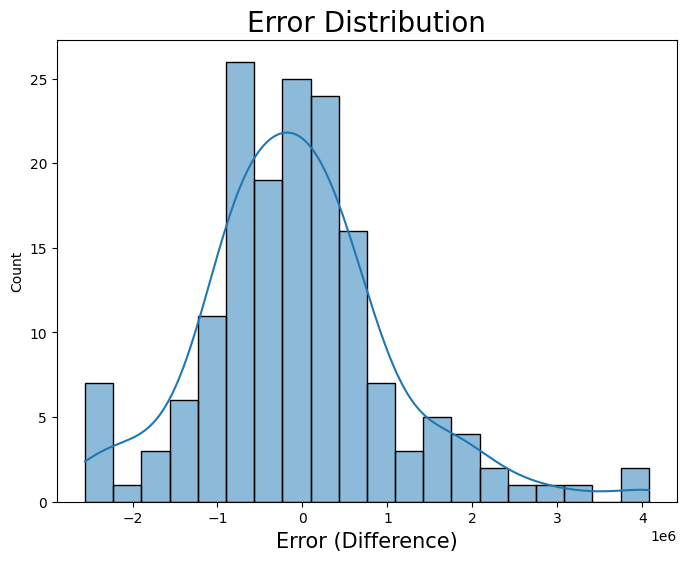

In [11]:
# Visualization (Graphs)
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import numpy as np
import os

file_path = 'model/house_model.pkl'
model = pickle.load(open(file_path, 'rb'))
# Predictions nikal rahe hain (Agar upar nahi nikale to)
y_pred = model.predict(X_test)

# 1. Actual vs Predicted Graph
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue') # Blue dots
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r', lw=2) # Red line (Perfect)
plt.title('Actual vs Predicted Prices', fontsize=20)
plt.xlabel('Actual Price', fontsize=15)
plt.ylabel('Predicted Price (Model)', fontsize=15)
plt.show()

# 2. Error Graph (Residuals)
plt.figure(figsize=(8,6))
sns.histplot((y_test - y_pred), kde=True, bins=20)
plt.title('Error Distribution', fontsize=20)
plt.xlabel('Error (Difference)', fontsize=15)
plt.show()